In [1]:
!pip install pymupdf sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 64.2 MB/s eta 0:00:00


In [2]:
!pip install pypdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 338.8/338.8 kB 4.8 MB/s eta 0:00:00


In [3]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pypdf import PdfReader
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

transformar PDFs → texto limpo → embeddings → similarity scores

In [4]:
def extract_text_from_pdf(pdf_path):
    try:
        reader = PdfReader(pdf_path)
        text = "".join(
            [page.extract_text() for page in reader.pages if page.extract_text()]
        )
        return text
    except:
        return ""

In [5]:
embedder = SentenceTransformer('all-MiniLM-L6-v2')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [6]:
BASE_PATH = "CV-Analyzer-Agent"

cv_files = glob.glob(f"{BASE_PATH}/CVs/*.pdf")
jd_files = glob.glob(f"{BASE_PATH}/JobDescriptions/*.pdf")

print("CVs:", len(cv_files))
print("JDs:", len(jd_files))

CVs: 107
JDs: 5


In [7]:
cv_database = []

for path in cv_files:
    text = extract_text_from_pdf(path)
    if text:
        cv_database.append({
            "name": os.path.basename(path),
            "text": text
        })

cv_df = pd.DataFrame(cv_database)

In [8]:
job_names = {
    "JobDescription1": "Directors, Data & AI Strategy",
    "JobDescription2": "Senior Consultant, Technology Risk",
    "JobDescription3": "Cybersecurity Team Recruitment",
    "JobDescription4": "Financial Analyst",
    "JobDescription5": "Consultant, Forensic & Integrity Services"
}

jd_database = {}

for path in jd_files:
    name = os.path.basename(path).replace(".pdf", "")

    jd_database[job_names[name]] = extract_text_from_pdf(path)

In [9]:
def get_match_score(cv_text, jd_text):
    emb = embedder.encode([cv_text, jd_text])
    return cosine_similarity([emb[0]], [emb[1]])[0][0]

In [10]:
# escolher vagas
job_title = list(jd_database.keys())[4]
jd_text = jd_database[job_title]

In [11]:
print(job_title)

Cybersecurity Team Recruitment


In [12]:
print(jd_text)

Cybersecurity Team Recruitment 
Location: Lisbon, Portugal 
Department: Cybersecurity 
Experience Level: N/A 
 
About the Role: 
EY Portugal is embarking on an exciting journey to establish a 
comprehensive Cybersecurity practice from the ground up. We are seeking 
to recruit an entire team of cybersecurity professionals with diverse 
expertise to build a robust cybersecurity framework that protects our 
clients and their assets. 
 
Key Responsibilities: 
 
Develop and implement a comprehensive cybersecurity strategy tailored to 
client needs. 
Establish cybersecurity policies, procedures, and best practices. 
Conduct risk assessments and vulnerability assessments to identify 
potential threats. 
Foster a culture of security awareness within the organization and among 
clients. 
Collaborate with stakeholders to ensure alignment with business 
objectives and compliance with regulations. 
Stay current with emerging cybersecurity threats and trends, adapting 
strategies as necessary. 
Req

In [13]:
results = []

for cv in cv_database:
    score = get_match_score(cv["text"], jd_text)

    results.append({
        "Candidate": cv["name"],
        "Score": score
    })

df = pd.DataFrame(results)

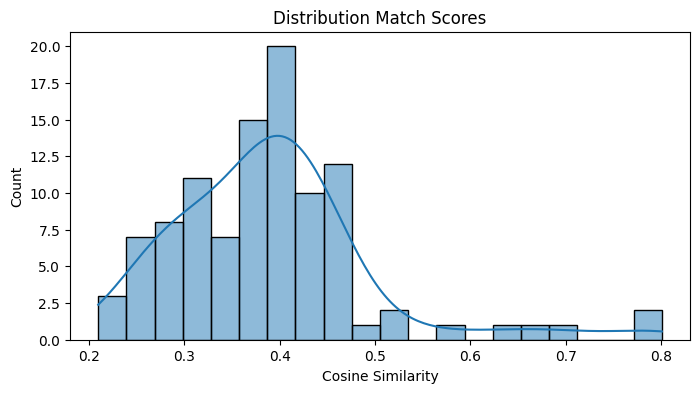

In [32]:
plt.figure(figsize=(8,4))
sns.histplot(df["Score"], bins=20, kde=True)
plt.title("Distribution Match Scores")
plt.xlabel("Cosine Similarity")
plt.show()

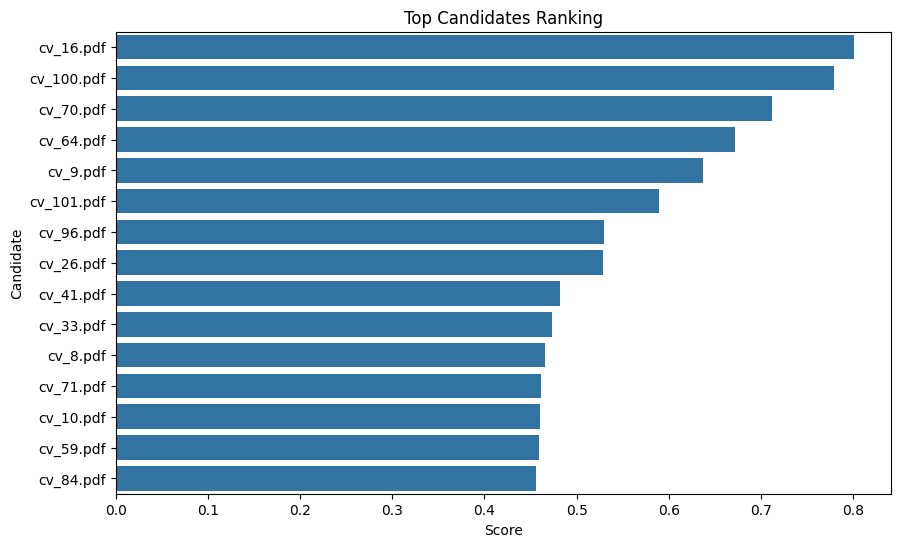

In [16]:
df_sorted = df.sort_values("Score", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(
    data=df_sorted.head(15),
    y="Candidate",
    x="Score"
)

plt.title("Top Candidates Ranking")
plt.show()

In [20]:
jobs = list(jd_database.keys())

results = []

for cv in cv_database:
    row = {"Candidate": cv["name"]}

    for job in jobs:
        score = get_match_score(cv["text"], jd_database[job])
        row[job] = score

    results.append(row)

df_matrix = pd.DataFrame(results)
df_matrix

,Candidate,Financial Analyst,"Senior Consultant, Technology Risk","Directors, Data & AI Strategy","Consultant, Forensic & Integrity Services",Cybersecurity Team Recruitment
0,cv_56.pdf,0.495429,0.408769,0.316717,0.455652,0.299964
1,cv_11.pdf,0.577527,0.383112,0.292971,0.374236,0.295327
2,cv_65.pdf,0.496232,0.454647,0.448062,0.490069,0.421027
3,cv_97.pdf,0.401374,0.497946,0.536237,0.488066,0.449860
4,cv_101.pdf,0.384660,0.638209,0.514968,0.552607,0.589690
...,...,...,...,...,...,...
97,cv_23.pdf,0.229227,0.319635,0.248552,0.345056,0.336008
98,cv_10.pdf,0.324714,0.438689,0.445419,0.512448,0.460074
99,cv_91.pdf,0.301026,0.318166,0.279413,0.440356,0.327118
100,cv_89.pdf,0.368332,0.425051,0.350503,0.386639,0.410685


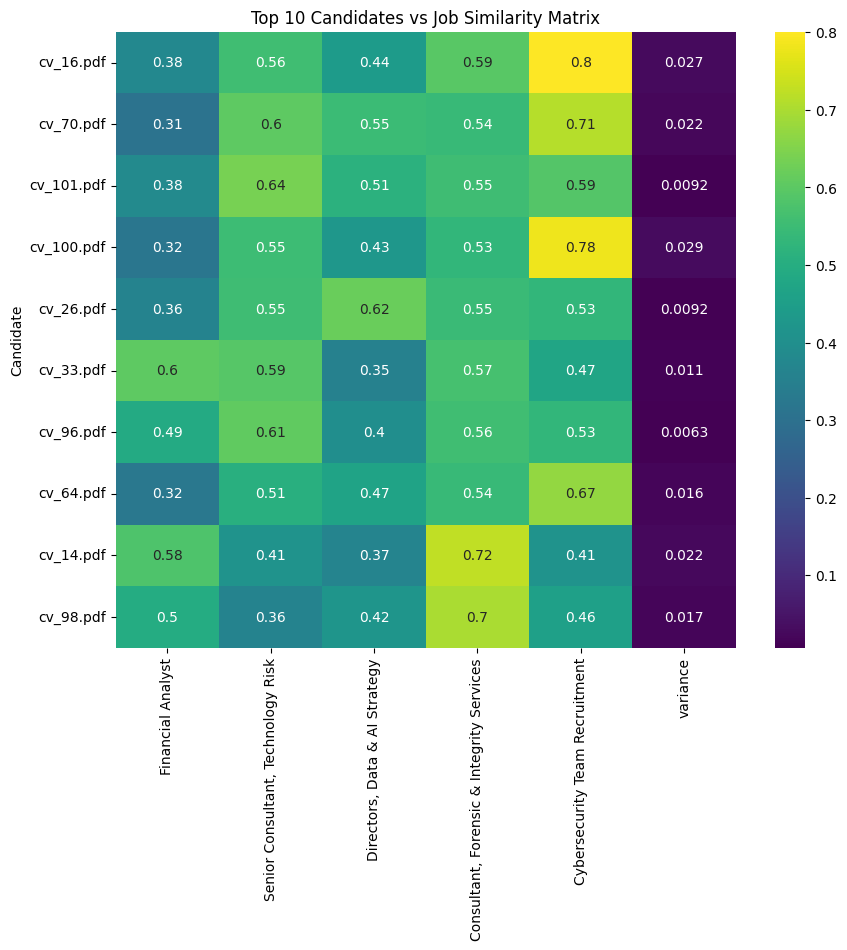

In [27]:
# 1. Define 'Candidate' como índice
df_indexado = df_matrix.set_index("Candidate")

# 2. Encontra os 10 melhores somando as similaridades de todas as colunas
top_10_index = df_indexado.sum(axis=1).nlargest(10).index

# 3. Filtra o DataFrame apenas com os 10 melhores
df_top10 = df_indexado.loc[top_10_index]

# 4. Plota o heatmap
plt.figure(figsize=(10,8))

sns.heatmap(
    df_top10,
    cmap="viridis",
    annot=True # Dica: 'annot=True' exibe os números dentro do gráfico
)

plt.title("Top 10 Candidates vs Job Similarity Matrix")
plt.show()

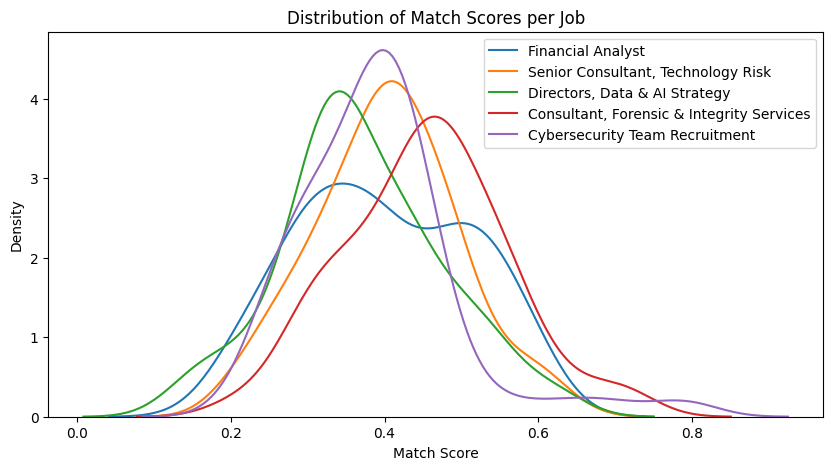

In [30]:
plt.figure(figsize=(10,5))

for job in jobs:
    sns.kdeplot(df_matrix[job], label=job)

plt.title("Distribution of Match Scores per Job")
plt.xlabel("Match Score")
plt.ylabel("Density")
plt.legend()
plt.show()

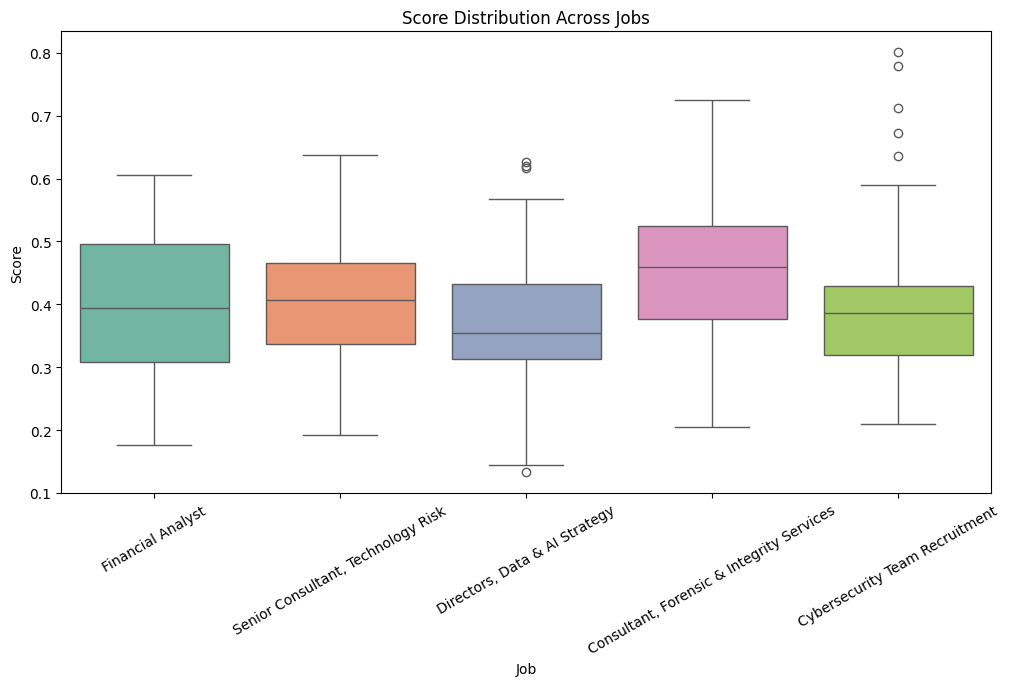

In [28]:
df_melt = df_matrix.melt(
    id_vars="Candidate",
    value_vars=jobs,
    var_name="Job",
    value_name="Score"
)

plt.figure(figsize=(12,6))

sns.boxplot(
    data=df_melt,
    x="Job",
    y="Score",
    hue="Job",       # <-- Define uma cor diferente para cada Job
    palette="Set2",  # <-- Escolhe uma paleta de cores (opcional)
    legend=False     # <-- Oculta a legenda redundante (recomendado)
)

plt.xticks(rotation=30)
plt.title("Score Distribution Across Jobs")
plt.show()

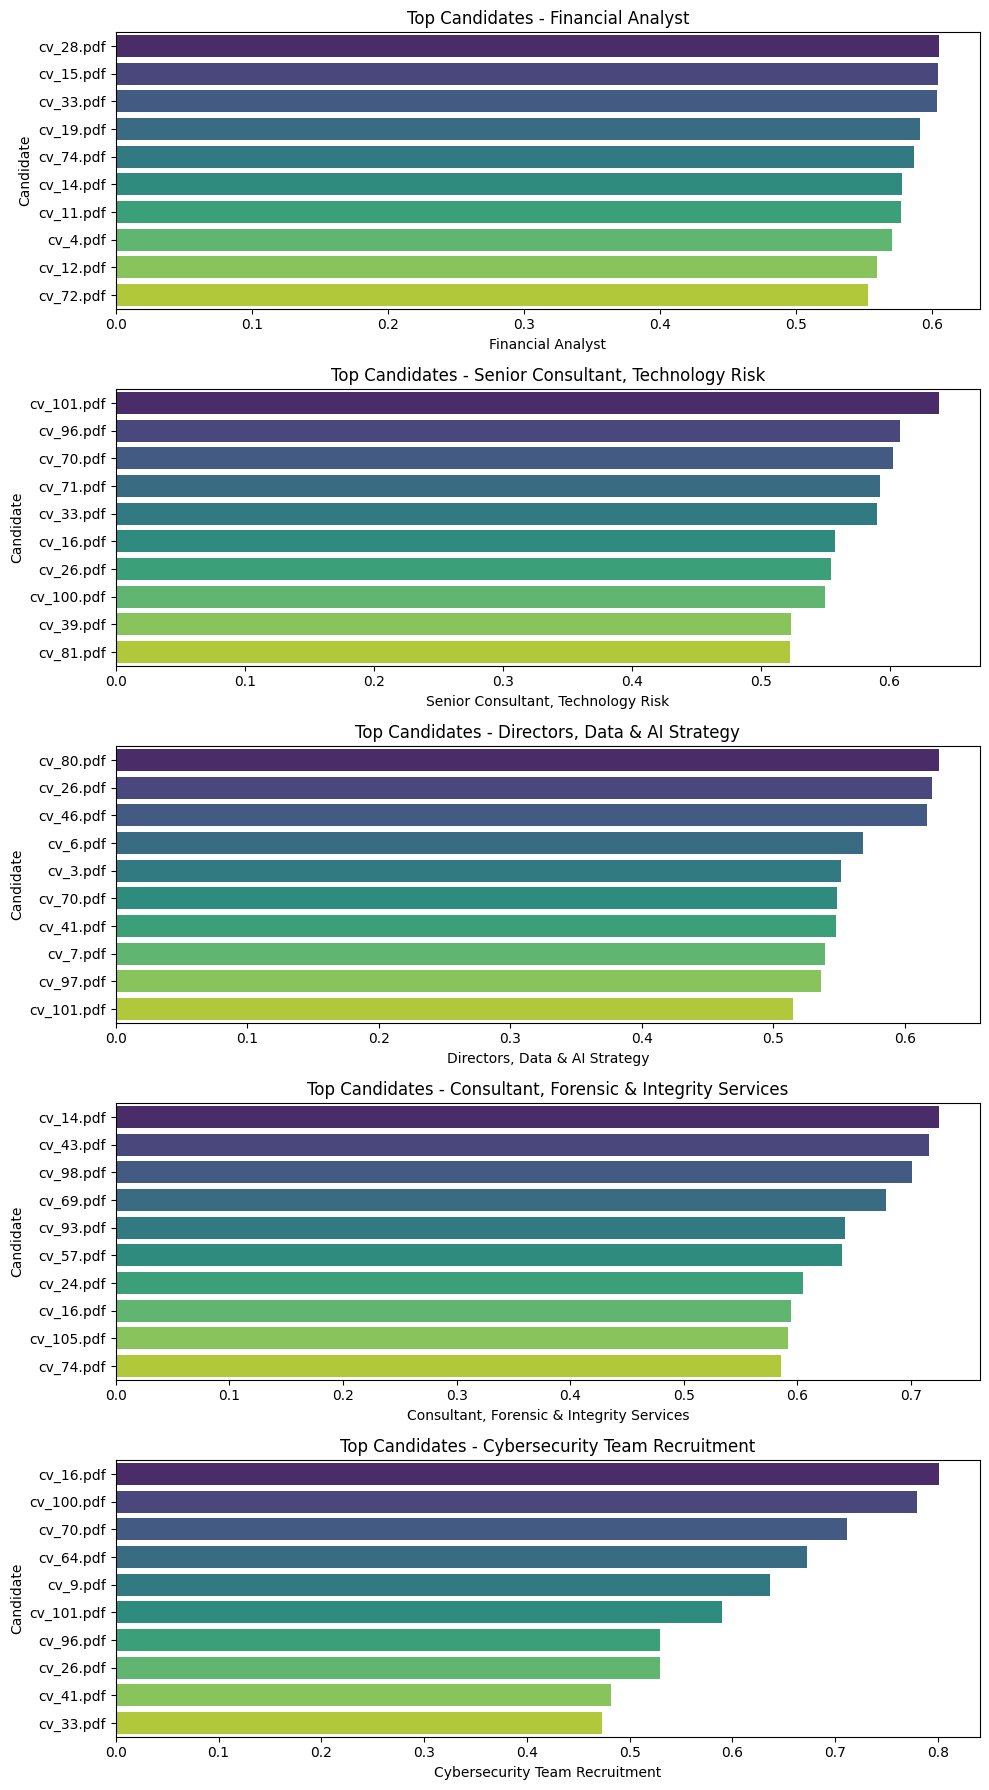

In [29]:
fig, axes = plt.subplots(len(jobs), 1, figsize=(10, 18))

for i, job in enumerate(jobs):
    # Pega os 10 melhores candidatos para a vaga atual no loop
    top = df_matrix[["Candidate", job]].sort_values(job, ascending=False).head(10)

    sns.barplot(
        data=top,
        y="Candidate",
        x=job,
        ax=axes[i],
        hue="Candidate",  # <-- Define uma cor diferente para cada candidato
        palette="viridis", # <-- Paleta de cores (pode escolher outra)
        legend=False      # <-- Remove a legenda lateral que seria repetitiva
    )

    axes[i].set_title(f"Top Candidates - {job}")

plt.tight_layout()
plt.show()

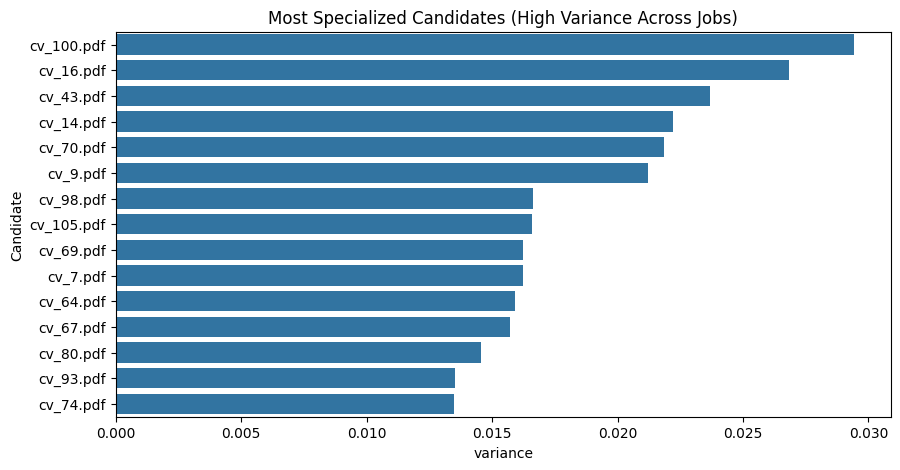

In [35]:
df_matrix["variance"] = df_matrix[jobs].var(axis=1)

df_sorted = df_matrix.sort_values("variance", ascending=False)

plt.figure(figsize=(10,5))

sns.barplot(
    data=df_sorted.head(15),
    x="variance",
    y="Candidate"
)

plt.title("Most Specialized Candidates (High Variance Across Jobs)")
plt.show()

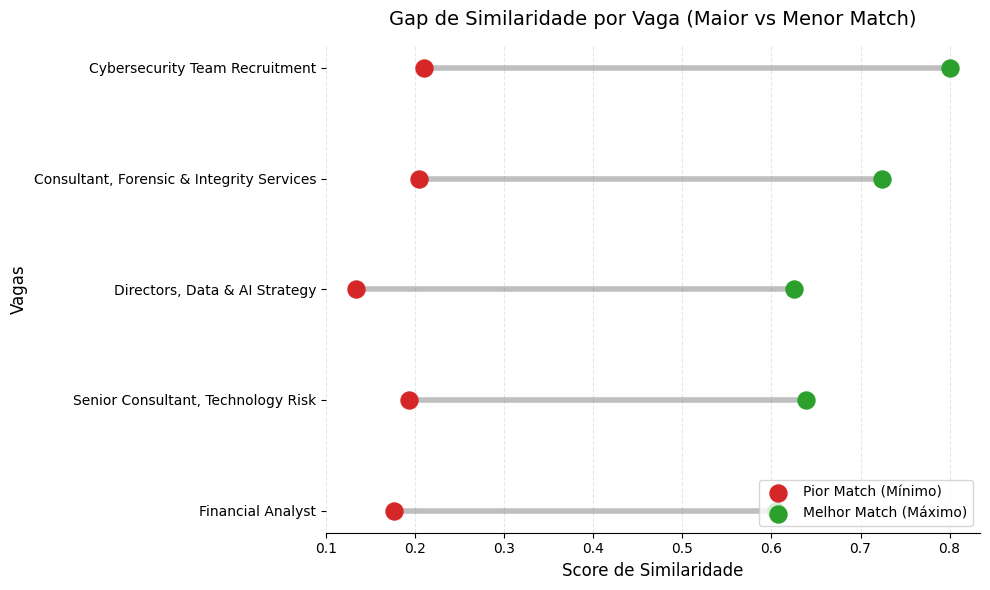

In [33]:
# 1. Primeiro criamos um resumo com a Nota Máxima e Mínima de cada vaga
df_gaps = pd.DataFrame({
    'Job': jobs,
    'Min_Score': [df_matrix[job].min() for job in jobs],
    'Max_Score': [df_matrix[job].max() for job in jobs]
})

plt.figure(figsize=(10, 6))

# 2. Desenha a linha conectando o Mínimo e o Máximo (Este é o "Gap" visual)
plt.hlines(
    y=df_gaps['Job'],
    xmin=df_gaps['Min_Score'],
    xmax=df_gaps['Max_Score'],
    color='grey',
    alpha=0.5,
    linewidth=4
)

# 3. Desenha a bolinha da Menor Nota
plt.scatter(
    df_gaps['Min_Score'],
    df_gaps['Job'],
    color='#d62728', # Vermelho
    s=150,
    label='Pior Match (Mínimo)',
    zorder=3
)

# 4. Desenha a bolinha da Maior Nota
plt.scatter(
    df_gaps['Max_Score'],
    df_gaps['Job'],
    color='#2ca02c', # Verde
    s=150,
    label='Melhor Match (Máximo)',
    zorder=3
)

# Configurações estéticas
plt.title("Gap de Similaridade por Vaga (Maior vs Menor Match)", fontsize=14, pad=15)
plt.xlabel("Score de Similaridade", fontsize=12)
plt.ylabel("Vagas", fontsize=12)
plt.legend(loc='lower right')
plt.grid(axis='x', linestyle='--', alpha=0.3)

# Remove a borda superior e direita para deixar mais "limpo" (opcional)
sns.despine(left=True)

plt.tight_layout()
plt.show()